# Solution for exercise 4

## Task 1

In [10]:
#Importing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ISLP import load_data
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize_scalar
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.cluster import AgglomerativeClustering

AttributeError: module 'matplotlib' has no attribute 'get_data_path'

In [ ]:
#Read data
Iris = pd.read_csv('iris.csv')

X = Iris.drop(columns = 'type')
y = Iris['type']

In [ ]:
#Scales for StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
kmeans = KMeans(n_clusters = 3, random_state = 1, n_init = 10)
kmeans.fit(X_scaled)
labels = kmeans.labels_

NameError: name 'KMeans' is not defined

In [ ]:
#Comparison
comparison = pd.crosstab(labels, y, rownames =  ['Cluster'], colnames = ['Type'])
print(comparison)

NameError: name 'labels' is not defined

In [ ]:
#Plot to visualize
plt.scatter(X_scaled[:, 0], X_scaled[:, 2], c = labels)
plt.xlabel('Sepal length (standardized)')
plt.ylabel('Petal length (standardized)')
plt.title('K-means clusters (K = 3)')
plt.show()

NameError: name 'plt' is not defined

### b)
***

In [ ]:
HClust = AgglomerativeClustering
hc = HClust(distance_threshold=0, n_clusters=None, linkage='complete')  # complete linkage
hc.fit(X)
linkage_mat = compute_linkage(hc)  # konverter til scipy-format for dendrogram
dendrogram(linkage_mat, no_labels=True); plt.show()

clusters = cut_tree(linkage_mat, n_clusters=3).reshape(-1)  # kutt dendrogram ved K
print(pd.crosstab(clusters, y_true))

NameError: name 'AgglomerativeClustering' is not defined

In [ ]:
#Hierarchical cluster analysis
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import (dendrogram, cut_tree)
from ISLP.cluster import compute_linkage

In [ ]:
HClust = AgglomerativeClustering

hc_comp = HClust(distance_threshold = 0, n_clusters = None, linkage = 'complete')

In [ ]:
hc_comp.fit(X)
linkage_comp = compute_linkage(hc_comp)

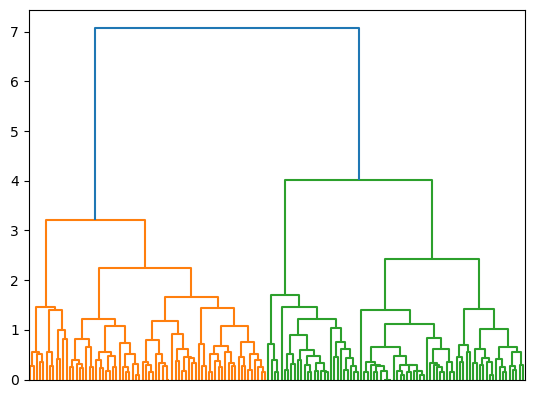

In [ ]:
fig, ax = plt.subplots()

ddata = dendrogram(linkage_comp, ax = ax, labels = X.index.to_list(), leaf_rotation = 45, leaf_font_size = 8, no_labels = True)
plt.show()

In [ ]:
clusters_3 = cut_tree(linkage_comp, n_clusters = 3).reshape(-1)
np.column_stack((y.values, clusters_3 ))[0:5]

array([['Iris-setosa', 0],
       ['Iris-setosa', 0],
       ['Iris-setosa', 0],
       ['Iris-setosa', 0],
       ['Iris-setosa', 0]], dtype=object)

## Task 2
***

### a)
***

In [ ]:
Hitters = load_data('Hitters')
Hitters.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


In [ ]:
Hitters = Hitters.dropna(subset = ['Salary']).copy()

Hitters['logSalary'] = np.log(Hitters['Salary'])

n = len(Hitters)
ntrain = np.int16(n/2)
ind = np.random.choice(n, size = ntrain, replace = False)
mask = np.ones(n, dtype = bool)
mask[ind] = False
train = Hitters.iloc[ind]
test = Hitters.iloc[mask]

def RSS(s, x1, y):
    yR1 = y[x1 < s].mean()
    yR2 = y[x1 >= s].mean()
    rss = ((y[x1 < s] - yR1) ** 2).sum() + ((y[x1 >= s] - yR2) **2).sum()

    return rss

res_hits = minimize_scalar(
    RSS,
    bounds = (0, 250),
    args = (train['Hits'].values, train['logSalary'].values),
    method = 'bounded'
)

res_years = minimize_scalar(
    RSS,
    bounds = (0, 50),
    args = (train['Years'].values, train['logSalary'].values),
    method = 'bounded'
)

res_hits, res_years

<positron-console-cell-13>:15: RuntimeWarning: Mean of empty slice
/opt/anaconda3/envs/BAN404/lib/python3.11/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


( message: Solution found.
  success: True
   status: 0
      fun: 70.9238374795346
        x: 125.15551180954549
      nit: 27
     nfev: 27,
  message: Solution found.
  success: True
   status: 0
      fun: 54.977148789766844
        x: 4.305220198368423
      nit: 29
     nfev: 29)

### b)
***

In [ ]:
#DecisionTreeRegressor
X_train = train[['Hits', 'Years']]
y_train = train['logSalary']

In [ ]:
tree1 = DecisionTreeRegressor(random_state = 0, min_samples_leaf = 15, max_depth = 3)
tree1.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",15
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf

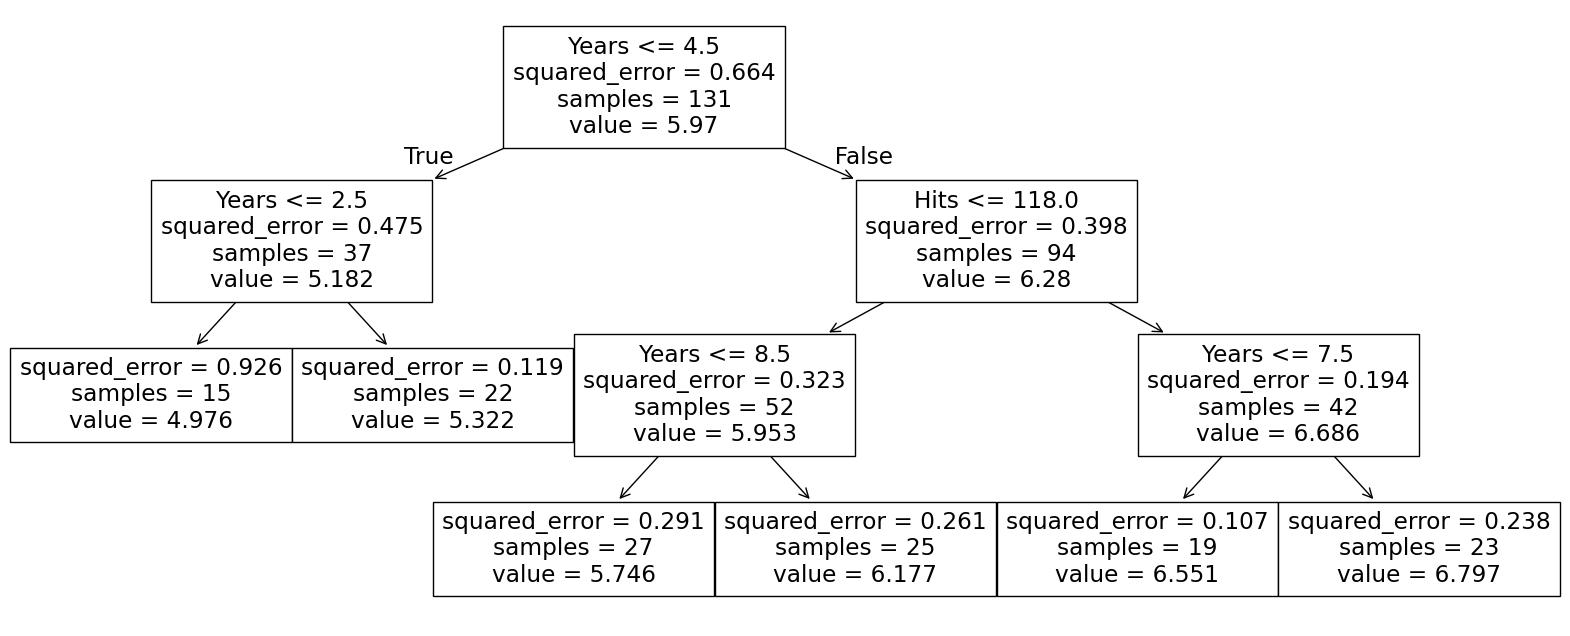

In [ ]:
fig, ax = plt.subplots(figsize = (20, 8))
plot_tree(tree1, feature_names = ['Hits', 'Years'], ax = ax)
plt.savefig('test.pdf', bbox_inches = 'tight')
plt.show()

### c)
***

In [ ]:
#Observation fo 125 hits and 2.5 years
new_obs = pd.DataFrame({'Hits' : [125], 'Years' : [2.5]})
new_obs

,Hits,Years
0,125,2.5


In [ ]:
log_pred = tree1.predict(new_obs)
salary_pred = np.exp(log_pred)

print(f"Predicted logSalary: {log_pred[0]:.4f}")
print(f"Predicted salary: {salary_pred[0]:.4f}")

Predicted logSalary: 4.9756
Predicted salary: 144.8339


### d)
***

In [ ]:
#Tree2 with all variables as predictors
X_train_all = train.drop(columns = ['logSalary', 'Salary'])
X_train_all = pd.get_dummies(X_train_all, drop_first = True)

tree2 = DecisionTreeRegressor(random_state = 0, min_samples_leaf = 30, max_depth = 5)
tree2.fit(X_train_all, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",30
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf

In [ ]:
#Predictions
pred1 = tree1.predict(X_train)
pred2 = tree2.predict(X_train_all)

y = train['logSalary'].values

In [ ]:
#TSS
TSS = ((y - y.mean()) ** 2).sum()

In [ ]:
#RSS
RSS1 = ((y - pred1) ** 2).sum()
RSS2 = ((y - pred2) ** 2).sum()

In [ ]:
#R2
R2_tree1 = (TSS - RSS1) / TSS
R2_tree2 = (TSS - RSS2) / TSS

In [ ]:
#Print
print(f"R2 tree1 (manual): {R2_tree1:.4f}")
print(f"R2 tree2 (manual): {R2_tree2:.4f}")

print(f"R2 tree1 (.score): {tree1.score(X_train, y_train):.4f}")
print(f"R2 tree2 (.score): {tree2.score(X_train_all, y_train):.4f}")

R2 tree1 (manual): 0.5587
R2 tree2 (manual): 0.5867
R2 tree1 (.score): 0.5587
R2 tree2 (.score): 0.5867


## Task 3
***

### a)
***

In [ ]:
#Testdata for tree 1
X_test = test[['Hits', 'Years']]
y_test = test['logSalary']
pred1 = tree1.predict(X_test)

#Testdata for tree 2
X2_test = test.drop(columns = ['Salary', 'logSalary'])
X2_test = pd.get_dummies(X2_test, drop_first = True)
pred2 = tree2.predict(X2_test)

In [ ]:
#MAD function
def MAD(y, pred):
    return np.mean(np.abs(y - pred))

print(f"Mean absolute error for tree 1: {MAD(y_test, pred1):.4f}")
print(f"Mean absolute error for tree 2: {MAD(y_test, pred2):.4f}")

Mean absolute error for tree 1: 0.4720
Mean absolute error for tree 2: 0.4930


### b)
***

In [ ]:
rf = RandomForestRegressor(n_estimators = 500, max_features = 6, random_state = 123)
rf.fit(X_train_all, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",6
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [ ]:
pred_rf = rf.predict(X2_test)
MADrf = MAD(y_test, pred_rf)
print(f"MAD = {MADrf:.4f}")

MAD = 0.3136


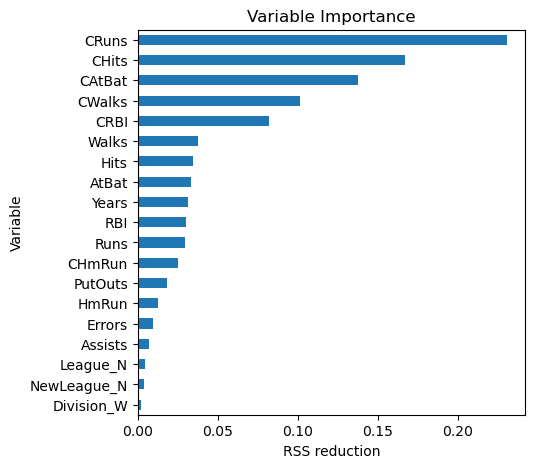

In [ ]:
#Variable importance
importances = pd.Series(rf.feature_importances_, index = X_train_all.columns)

plt.figure(figsize = (5, 5))
importances.sort_values().plot.barh()
plt.title('Variable Importance')
plt.xlabel('RSS reduction')
plt.ylabel('Variable')
plt.show()

### c)
***

In [ ]:
#Starting code from task
boost = GradientBoostingRegressor(n_estimators = 1000, learning_rate = 0.01, max_depth = 2, random_state = 123)

In [ ]:
#Fit
boost.fit(X_train_all, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.01
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",1000
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",2
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in thelef

In [ ]:
#Predictions
predboost = boost.predict(X2_test)
MADBoost = MAD(y_test, predboost)

print(f"MAD tree = {MAD(y_test, pred2):.4f} : MAD Boost = {MADBoost:.4f}")

MAD tree = 0.4930 : MAD Boost = 0.3246
